# Adult dataset

## Libraries and notebook setup

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # one level up

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pgmpy.estimators import BayesianEstimator
from src import effects
from src.effects import (
    DE,
    IE,
    SE,
    TE,
    TV,
    compute_categorical_fairness_report,
    compute_fairness_report,
    decompose_indirect_effect,
    decompose_spurious_effect,
)
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.preprocess import preprocess_adult_df
from src.visualisation.graph import visualize_sfm
from src.visualisation.sankey import plot_effect_sankey_percent
from src.llm import (
    prepare_llm_payload_general,
    payload_to_json,
    summarize_with_llm_combined,
)


/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv(override=True)  # loads OPENAI_API_KEY from .env

if os.getenv("OPENAI_API_KEY") is None:
    raise RuntimeError("OPENAI_API_KEY not found. ")


client = OpenAI()

## Standard Fairness Model (SFM): single mediator, single confounder [Example 1]

In this section we will work thorugh on presenting the first example of the paper.

Load the dataset, preprocess it, define the SFM on the given attributes. For such SFM we fit a Bayesian Network (BN) using `pgmpy`.

In [7]:
filepath = "data/processed/adult.csv"
df = pd.read_csv(filepath)
df = preprocess_adult_df(df)


selected_columns = [
    "relationship",
    "hours-per-week",
    "S2_gender",
    "T_income",
]
target_attr = "T_income"
private_attr = "S2_gender"
confounders = ["relationship"]
mediators = ["hours-per-week"]


In [8]:
df["T_income"].dtype
df["T_income"] = df["T_income"].astype("category")
df["relationship"].dtype
df["relationship"] = df["relationship"].astype("category")
df["S2_gender"].dtype
df["S2_gender"] = df["S2_gender"].astype("category")
df.head()


,S1_age,workclass,education,marital-status,occupation,relationship,S3_race,S2_gender,capital-gain,capital-loss,hours-per-week,native-country,T_income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,41-60,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,41-60,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,41-60,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,41-60,United-States,>50K
4,18,Other,Some-college,Never-married,Other,Own-child,White,Female,0,0,21-40,United-States,<=50K


2026-04-27 17:44:12.737 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'relationship': 'C', 'hours-per-week': 'O', 'S2_gender': 'C', 'T_income': 'C'}


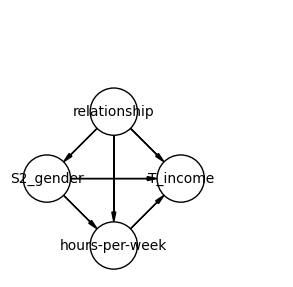

In [9]:
sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=target_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
    sorted_mediators=True,
    # latents=[("U", confounders), ("U", [private_attr])],
)

bn = fit_discrete_bayesian_model(
    sfm,
    df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()

visualize_sfm(sfm)

In [10]:
variable_metadata = pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

Let's compute the effect suite, namely the Total Variation (TV), Total Effect (TE), Experimental Spurious Effect (SE), Natural Direct Effect (DE), Natural Indirect Effect (IE). 

In [11]:
x0 = "Male"
x1 = "Female"
y_target = "<=50K"

tv = TV(bn, ("T_income", y_target), "S2_gender", "Male", "Female")
total_effect = TE(bn, ("T_income", y_target), "S2_gender", "Male", "Female")
se_male = SE(bn, ("T_income", y_target), "S2_gender", "Male")
se_female = SE(bn, ("T_income", y_target), "S2_gender", "Female")

assert total_effect + (se_female - se_male) == tv

nde_mf = DE(bn, ("T_income", y_target), "S2_gender", "Male", "Female")
nie_fm = IE(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

assert nde_mf - nie_fm == total_effect

print(f"Total Effect: {total_effect:.4f}")
print(f"Spurious Effect (Male): {se_male:.4f}")
print(f"Spurious Effect (Female): {se_female:.4f}")
print(f"Natural Direct Effect (Male->Female): {nde_mf:.4f}")
print(f"Natural Indirect Effect (Female->Male): {nie_fm:.4f}")
results = pd.Series(
    {
        "TV": tv,
        "TE": total_effect,
        "SE(x0)": se_male,
        "SE(x1)": se_female,
        "NDE": nde_mf,
        "NIE": nie_fm,
    },
    name="effect",
)


2026-04-27 17:44:15.802 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-04-27 17:44:15.805 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-04-27 17:44:15.807 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


Total Effect: 0.0225
Spurious Effect (Male): -0.0523
Spurious Effect (Female): 0.1191
Natural Direct Effect (Male->Female): 0.0473
Natural Indirect Effect (Female->Male): 0.0248


We can further compute the decompoisitions for the spurious and mediator effects. Since we are in a setup where there is a single mediator and a single confounder, we expect such decompositions to match the single effects computed above.

In [12]:
spurious_decomposition_male = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Male"
)
spurious_decomposition_female = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female"
)
indirect_decomposition = decompose_indirect_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female", "Male"
)

assert np.allclose(se_male, spurious_decomposition_male[confounders[0]])
assert np.allclose(se_female, spurious_decomposition_female[confounders[0]])
assert np.allclose(nie_fm, indirect_decomposition[mediators[0]])

2026-04-27 17:44:17.011 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=[], Z_B=['relationship']
2026-04-27 17:44:17.012 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Female, Z_A=[], Z_B=['relationship']
2026-04-27 17:44:17.014 | DEBUG    | src.effects:set_specific_indirect_effect:915 - Computing set-specific indirect effect for
            target=('T_income', '<=50K'),
            private_baseline=Female,
            private_mod=Male,
            first_mediator_partition=[],
            second_mediator_partition=['hours-per-week'],
            ordered_mediators=['hours-per-week']


We can plot the effects and how they relate within each other in a Sankey Plot.

se = se_female - se_male

plot_effect_sankey_percent(
    target_name="T_income",
    private_name="S2_gender",
    tv=tv,
    te=total_effect,
    se={"Male": se_male, "Female": se_female},
    # se={"": se},
    ie=nie_fm,
    de=nde_mf,
    # se_decomp={
    #     "Male": spurious_decomposition_male,
    #     "Female": spurious_decomposition_female,
    # },
    # ie_decomp=indirect_decomposition,
    title=f"Causal Fairness Decomposition: Income <=50k (|TV| = {tv * 100:.2f}%)",
    save_path="./results/adult_sankey",
)

In [13]:
report_1 = compute_fairness_report(
    bn,
    target=("T_income", "<=50K"),
    private_attr="S2_gender",
    x0="Male",
    x1="Female",
)
report_1

2026-04-27 17:44:18.502 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-04-27 17:44:18.505 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-04-27 17:44:18.506 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female
2026-04-27 17:44:18.510 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=[], Z_B=['relationship']
2026-04-27 17:44:18.512 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Female, Z_A=[], Z_B=['relationship']
2026-04-27 17:44:18.512 | DEBUG    | src.effects:set_specific_indirect_effect:915 - Computing set-specific indi

,target_attr,target,private_attr,private_baseline,private_mod,effect,variable,value,% of |TV|
0,T_income,<=50K,S2_gender,Male,Female,TV,—,0.193900,100.00
1,T_income,<=50K,S2_gender,Male,Female,TE,—,0.022492,11.60
2,T_income,<=50K,S2_gender,Male,Female,SE[Male],—,-0.052268,26.96
3,T_income,<=50K,S2_gender,Male,Female,SE[Female],—,0.119140,61.44
4,T_income,<=50K,S2_gender,Male,Female,NDE,—,0.047263,24.38
5,T_income,<=50K,S2_gender,Male,Female,NIE,—,0.024772,12.78
6,T_income,<=50K,S2_gender,Male,Female,SE[Male],relationship,-0.052268,26.96
7,T_income,<=50K,S2_gender,Male,Female,SE[Female],relationship,0.119140,61.44
8,T_income,<=50K,S2_gender,Male,Female,NIE,hours-per-week,0.024772,12.78


LLM report

In [14]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [15]:
payload = prepare_llm_payload_general(
    dataset_name="Adult Dataset",
    X=private_attr,
    Y=target_attr,
    W=mediators,
    Z=confounders,
    x0=x0,
    x1=x1,
    y_target=y_target,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    graph_edges=sorted(sfm.edges()),
)

In [16]:
payload_json = payload_to_json(payload)

In [ ]:
text, latex_doc, token_usage = summarize_with_llm_combined(payload_json, client)

In [ ]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}
\section*{Title: "Fairness Decomposition Report"}

\subsection*{Overview of the Fairness Analysis}
This analysis examines fairness in the Adult Dataset by decomposing the observed difference in the probability of T\_income (target $Y \leq 50K$) between S2\_gender groups: Male (x0) vs Female (x1). The decomposition separates the observed total variation into a causal total effect (TE), a natural direct effect (NDE), a natural indirect effect (NIE) through the mediator hours-per-week, and spurious effects associated with the confounder relationship. The mediator included is hours-per-week and the confounder is relationship. No continuous threshold/curve data were provided; trend-over-threshold cannot be assessed.

\subsection*{Decomposition of Effects}
\begin{itemize}
\item Total variation (TV) between Male (x0) and Female (x1): $0.1939$. Interpretation: the observed marginal differe

## SFM (2 mediators, 2 confounders) [Example 2]

2026-03-12 18:44:43.980 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'relationship': 'C', 'hours-per-week': 'O', 'S2_gender': 'C', 'T_income': 'C', 'occupation': 'C', 'native-country': 'C'}


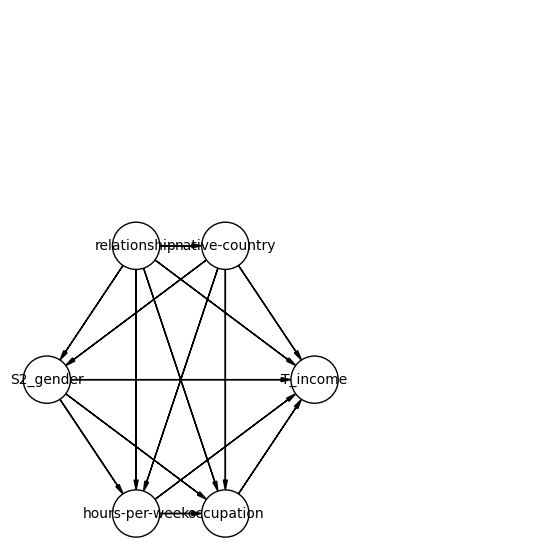

In [ ]:
target_attr = "T_income"
private_attr = "S2_gender"
confounders = ["relationship", "native-country"]
mediators = ["hours-per-week", "occupation"]
df["occupation"] = df["occupation"].astype("category")
df["native-country"] = df["native-country"].astype("category")
df.head()

selected_columns = [
    "relationship",
    "hours-per-week",
    "S2_gender",
    "T_income",
    "occupation",
    "native-country",
]


sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=target_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
    sorted_mediators=True,
    sorted_confounders=True,
)

bn = fit_discrete_bayesian_model(
    sfm,
    df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()

visualize_sfm(sfm)
x0 = "Male"
x1 = "Female"
y_target = "<=50K"

In [ ]:
variable_metadata = pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

In [ ]:
tv = TV(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
total_effect = TE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
se_male = SE(bn, ("T_income", "<=50K"), "S2_gender", "Male")
se_female = SE(bn, ("T_income", "<=50K"), "S2_gender", "Female")

assert total_effect + (se_female - se_male) == tv

nde_mf = DE(bn, ("T_income", "<=50K"), "S2_gender", "Male", "Female")
nie_fm = IE(
    bn,
    ("T_income", "<=50K"),
    "S2_gender",
    "Female",
    "Male",
)

assert nde_mf - nie_fm == total_effect
results = pd.Series(
    {
        "TV": tv,
        "TE": total_effect,
        "SE(x0)": se_male,
        "SE(x1)": se_female,
        "NDE": nde_mf,
        "NIE": nie_fm,
    },
    name="effect",
)

y_target = "<=50K"

2026-03-12 18:45:29.315 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-12 18:45:29.321 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-12 18:45:29.323 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female


In [ ]:
spurious_decomposition_male = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Male"
)
spurious_decomposition_female = decompose_spurious_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female"
)
indirect_decomposition = decompose_indirect_effect(
    bn, ("T_income", "<=50K"), "S2_gender", "Female", "Male"
)

# assert np.allclose(se_male, spurious_decomposition_male[confounders[0]])
# assert np.allclose(se_female, spurious_decomposition_female[confounders[0]])
# assert np.allclose(nie_fm, indirect_decomposition[mediators[0]])

2026-03-12 18:45:31.179 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=[], Z_B=['relationship']
2026-03-12 18:45:31.181 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=['relationship'], Z_B=['relationship', 'native-country']
2026-03-12 18:45:31.183 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Female, Z_A=[], Z_B=['relationship']
2026-03-12 18:45:31.185 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Female, Z_A=['relationship'], Z_B=['relationship', 'native-country']
2026-03-12 18:45:31.186 | DEBUG    | src.effects:set_specific_indirect_effect:915 - Computing set-specific i

In [ ]:
se = se_female - se_male

plot_effect_sankey_percent(
    target_name="T_income",
    private_name="S2_gender",
    tv=tv,
    te=total_effect,
    se={"Male": se_male, "Female": se_female},
    ie=nie_fm,
    de=nde_mf,
    se_decomp={
        "Male": spurious_decomposition_male,
        "Female": spurious_decomposition_female,
    },
    ie_decomp=indirect_decomposition,
    # title=f"Causal Fairness Decomposition: Income <=50k (|TV| = {tv * 100:.2f}%)",
    title="",
    save_path="./results/adult_sankey_2_2",
)

NameError: name 'se_female' is not defined

In [ ]:
report_2 = compute_fairness_report(
    bn,
    target=("T_income", "<=50K"),
    private_attr="S2_gender",
    x0="Male",
    x1="Female",
)
report_2

2026-03-12 18:45:34.801 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Male, private_mod=Female
2026-03-12 18:45:34.807 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Male
2026-03-12 18:45:34.810 | DEBUG    | src.effects:spurious_effect:195 - Computing spurious effect for target=('T_income', '<=50K'), private_value=Female
2026-03-12 18:45:34.819 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=[], Z_B=['relationship']
2026-03-12 18:45:34.821 | DEBUG    | src.effects:set_specific_spurious_effect:1057 - Computing set-specific spurious effect for target=('T_income', '<=50K'), private_attr=Male, Z_A=['relationship'], Z_B=['relationship', 'native-country']
2026-03-12 18:45:34.823 | DEBUG    | src.effects:set_specific_spurious_effect:105

,target_attr,target,private_attr,private_baseline,private_mod,effect,variable,value,% of |TV|
0,T_income,<=50K,S2_gender,Male,Female,TV,—,0.173608,100.00
1,T_income,<=50K,S2_gender,Male,Female,TE,—,0.005315,3.06
2,T_income,<=50K,S2_gender,Male,Female,SE[Male],—,-0.043638,25.14
3,T_income,<=50K,S2_gender,Male,Female,SE[Female],—,0.124655,71.80
4,T_income,<=50K,S2_gender,Male,Female,NDE,—,-0.005065,2.92
5,T_income,<=50K,S2_gender,Male,Female,NIE,—,-0.010380,5.98
6,T_income,<=50K,S2_gender,Male,Female,SE[Male],relationship,-0.042986,24.76
7,T_income,<=50K,S2_gender,Male,Female,SE[Male],native-country,-0.000652,0.38
8,T_income,<=50K,S2_gender,Male,Female,SE[Female],relationship,0.125544,72.31
9,T_income,<=50K,S2_gender,Male,Female,SE[Female],native-country,-0.000889,0.51


LLM report

In [ ]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [ ]:
payload = prepare_llm_payload_general(
    dataset_name="Adult Dataset",
    X=private_attr,
    Y=target_attr,
    W=mediators,
    Z=confounders,
    x0=x0,
    x1=x1,
    y_target=y_target,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    graph_edges=sorted(sfm.edges()),
    se_decomp={
        "Male": spurious_decomposition_male,
        "Female": spurious_decomposition_female,
    },
    ie_decomp=indirect_decomposition,
)

In [ ]:
payload_json = payload_to_json(payload)

In [ ]:
text, latex_doc, token_usage = summarize_with_llm_combined(payload_json, client)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


In [ ]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}

Title: "Fairness Decomposition Report"

\subsection*{Overview of the Fairness Analysis}
This analysis examines disparities in the Adult Dataset comparing S2\_gender = Male (x0) versus S2\_gender = Female (x1). The outcome $T\_income$ is the binary income target; the reported target event is $T\_income \leq 50K$. We decomposed the observed total variation in the probability of $T\_income \leq 50K$ into causal components (total effect, natural direct effect, natural indirect effect) and spurious (confounding) components, and we further decomposed the indirect and spurious pieces by mediators and confounders. The mediators are hours-per-week and occupation; the confounders are relationship and native-country.

\subsection*{Decomposition of Effects}
\begin{itemize}
  \item Total variation (TV): $0.1736$. This is the observed difference (Female minus Male) in the probability of $T\_inc

## SFM Race on Income

2026-03-11 14:39:56.706 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'N', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'N', 'capital-loss': 'N', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}
INFO:choreographer.utils._tmpfile:TemporaryDirectory.cleanup() worked.
INFO:choreographer.utils._tmpfile:shutil.rmtree worked.
INFO:choreographer.utils._tmpfile:TemporaryDirectory.cleanup() worked.
INFO:choreographer.utils._tmpfile:shutil.rmtree worked.


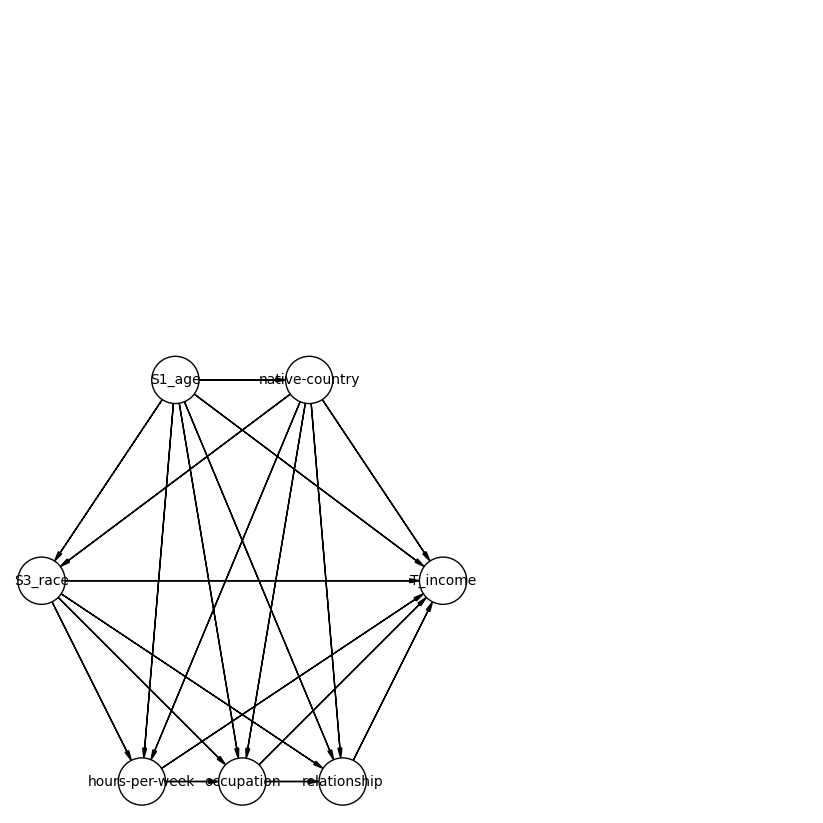

In [ ]:
target_attr = "T_income"
private_attr = "S3_race"
confounders = ["S1_age", "native-country"]
mediators = ["hours-per-week", "occupation", "relationship"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=target_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
    sorted_mediators=True,
    sorted_confounders=True,
)

bn = fit_discrete_bayesian_model(
    sfm,
    df,
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()

visualize_sfm(sfm)

In [ ]:
from src.effects import catTV, catTE, catNIE, catNDE

protected_states = ["Black", "Amer-Indian-Eskimo"]
unprotected_states = ["White", "Asian-Pac-Islander", "Other"]

cat_tv_res = catTV(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    unprotected_states,
    protected_states,
)

cat_te_res = catTE(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    unprotected_states,
    protected_states,
)

cat_nde_res = catNDE(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    unprotected_states,
    protected_states,
)

cat_nie_res = catNIE(
    bn,
    ("T_income", "<=50K"),
    private_attr,
    unprotected_states,
    protected_states,
)

2026-03-11 15:00:29.664 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=White, private_mod=Black
2026-03-11 15:00:29.689 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=White, private_mod=Amer-Indian-Eskimo
2026-03-11 15:00:29.714 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Asian-Pac-Islander, private_mod=Black
2026-03-11 15:00:29.740 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Asian-Pac-Islander, private_mod=Amer-Indian-Eskimo
2026-03-11 15:00:29.765 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Other, private_mod=Black
2026-03-11 15:00:29.789 | DEBUG    | src.effects:total_variation:248 - Computing to

In [ ]:
cat_tv_res.to_dataframe()

,x0,x1,effect
0,White,Black,-0.055920
1,White,Amer-Indian-Eskimo,-0.145505
2,Asian-Pac-Islander,Black,0.091850
3,Asian-Pac-Islander,Amer-Indian-Eskimo,0.002265
4,Other,Black,0.093927
5,Other,Amer-Indian-Eskimo,0.004342


In [ ]:
cat_te_res.to_dataframe()

,x0,x1,effect
0,White,Black,-0.039597
1,White,Amer-Indian-Eskimo,-0.126292
2,Asian-Pac-Islander,Black,0.091956
3,Asian-Pac-Islander,Amer-Indian-Eskimo,0.005261
4,Other,Black,0.095073
5,Other,Amer-Indian-Eskimo,0.008378


In [ ]:
cat_nie_res.to_dataframe()

,x0,x1,w,effect
0,White,Black,hours-per-week,-0.003045
1,White,Black,occupation,0.006846
2,White,Black,relationship,0.007144
3,White,Amer-Indian-Eskimo,hours-per-week,-0.024832
4,White,Amer-Indian-Eskimo,occupation,-0.013043
5,White,Amer-Indian-Eskimo,relationship,-0.015718
6,Asian-Pac-Islander,Black,hours-per-week,-0.000564
7,Asian-Pac-Islander,Black,occupation,-0.002886
8,Asian-Pac-Islander,Black,relationship,0.003007
9,Asian-Pac-Islander,Amer-Indian-Eskimo,hours-per-week,-0.002438


In [ ]:
cat_nde_res.to_dataframe()

,x0,x1,effect
0,White,Black,-0.070379
1,White,Amer-Indian-Eskimo,-0.126288
2,Asian-Pac-Islander,Black,0.029521
3,Asian-Pac-Islander,Amer-Indian-Eskimo,-0.003878
4,Other,Black,0.026776
5,Other,Amer-Indian-Eskimo,-0.002014


In [ ]:
from src.effects import compute_categorical_fairness_report

categorical_report = compute_categorical_fairness_report(
    bn,
    target=("T_income", "<=50K"),
    private_attr=private_attr,
    x0_set=unprotected_states,
    x1_set=protected_states,
)
categorical_report

2026-03-11 14:05:00.746 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=White, private_mod=Black
2026-03-11 14:05:00.938 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=White, private_mod=Amer-Indian-Eskimo
2026-03-11 14:05:00.964 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Asian-Pac-Islander, private_mod=Black
2026-03-11 14:05:00.988 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Asian-Pac-Islander, private_mod=Amer-Indian-Eskimo
2026-03-11 14:05:01.012 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('T_income', '<=50K'), private_baseline=Other, private_mod=Black
2026-03-11 14:05:01.036 | DEBUG    | src.effects:total_variation:248 - Computing to

,target_attr,target,private_attr,x0,x1,effect,component,value,tv_value,"% of |TV(x0,x1)|"
0,T_income,<=50K,S3_race,White,Black,Total Variation,aggregate,-0.055920,-0.055920,100.00
1,T_income,<=50K,S3_race,White,Amer-Indian-Eskimo,Total Variation,aggregate,-0.145505,-0.145505,100.00
2,T_income,<=50K,S3_race,Asian-Pac-Islander,Black,Total Variation,aggregate,0.091850,0.091850,100.00
3,T_income,<=50K,S3_race,Asian-Pac-Islander,Amer-Indian-Eskimo,Total Variation,aggregate,0.002265,0.002265,100.00
4,T_income,<=50K,S3_race,Other,Black,Total Variation,aggregate,0.093927,0.093927,100.00
5,T_income,<=50K,S3_race,Other,Amer-Indian-Eskimo,Total Variation,aggregate,0.004342,0.004342,100.00
6,T_income,<=50K,S3_race,White,Black,Total Effect,aggregate,-0.039597,-0.055920,70.81
7,T_income,<=50K,S3_race,White,Amer-Indian-Eskimo,Total Effect,aggregate,-0.126292,-0.145505,86.80
8,T_income,<=50K,S3_race,Asian-Pac-Islander,Black,Total Effect,aggregate,0.091956,0.091850,100.12
9,T_income,<=50K,S3_race,Asian-Pac-Islander,Amer-Indian-Eskimo,Total Effect,aggregate,0.005261,0.002265,232.31


In [ ]:
# Data analysis for categorical fairness report where x0=non-protected and x1=protected
rep = categorical_report.copy()

print("=== Report shape ===")
print(f"rows={len(rep)}, cols={len(rep.columns)}")
print("columns:", list(rep.columns))
print("\n=== Group cardinalities ===")
print("x0 states (non-protected):", sorted(rep["x0"].unique().tolist()))
print("x1 states (protected):", sorted(rep["x1"].unique().tolist()))

print("\n=== Effect and component space ===")
print("effects:", sorted(rep["effect"].dropna().unique().tolist()))
print("components:", sorted(rep["component"].dropna().unique().tolist()))

effect_aliases = {
    "TV": "Total Variation",
    "TE": "Total Effect",
    "NDE": "Natural Direct Effect (Decomposed)",
    "NIE": "Natural Indirect Effect",
}

# Use aggregate rows when available to avoid mixing decomposed mediator-level rows with pair-level summaries.
aggregate = rep[rep["component"] == "aggregate"].copy()
if aggregate.empty:
    aggregate = rep.copy()

available = {k: v for k, v in effect_aliases.items() if v in set(aggregate["effect"])}

if available:
    pair_metrics = (
        aggregate[aggregate["effect"].isin(available.values())]
        .pivot_table(
            index=["x0", "x1"], columns="effect", values="value", aggfunc="first"
        )
        .rename(columns={v: k for k, v in available.items()})
    )
    print("\n=== Pairwise core effects (x0, x1) ===")
    print(pair_metrics.round(6).to_string())

    print("\n=== Mean core effects by protected group (x1) ===")
    mean_by_x1 = (
        aggregate[aggregate["effect"].isin(available.values())]
        .groupby(["x1", "effect"])["value"]
        .mean()
        .unstack("effect")
        .rename(columns={v: k for k, v in available.items()})
    )
    print(mean_by_x1.round(6).to_string())

    print("\n=== Mean core effects by non-protected group (x0) ===")
    mean_by_x0 = (
        aggregate[aggregate["effect"].isin(available.values())]
        .groupby(["x0", "effect"])["value"]
        .mean()
        .unstack("effect")
        .rename(columns={v: k for k, v in available.items()})
    )
    print(mean_by_x0.round(6).to_string())

te_name = effect_aliases["TE"]
if te_name in set(aggregate["effect"]):
    te = aggregate[aggregate["effect"] == te_name][["x0", "x1", "value"]].rename(
        columns={"value": "TE"}
    )
    te["|TE|"] = te["TE"].abs()

    print("\n=== Top pairwise disparities by |TE| ===")
    print(
        te.sort_values("|TE|", ascending=False)
        .head(10)
        .drop(columns=["|TE|"])
        .round(6)
        .to_string(index=False)
    )

    print("\n=== Pairs where TE > 0 (x1 has higher target probability than x0) ===")
    te_pos = te[te["TE"] > 0].sort_values("TE", ascending=False)
    print(te_pos.head(10).round(6).to_string(index=False) if len(te_pos) else "None")

    print("\n=== Pairs where TE < 0 (x1 has lower target probability than x0) ===")
    te_neg = te[te["TE"] < 0].sort_values("TE", ascending=True)
    print(te_neg.head(10).round(6).to_string(index=False) if len(te_neg) else "None")

if effect_aliases["NDE"] in set(rep["effect"]):
    nde = rep[rep["effect"] == effect_aliases["NDE"]].copy()
    nde_comp = (
        nde[nde["component"] != "aggregate"]
        .groupby(["x1", "component"])["value"]
        .mean()
        .reset_index()
        .sort_values(["x1", "value"], ascending=[True, False])
    )
    if not nde_comp.empty:
        print("\n=== Mean NDE decomposition by protected group (x1, component) ===")
        print(nde_comp.round(6).to_string(index=False))

if effect_aliases["NIE"] in set(rep["effect"]):
    nie = rep[rep["effect"] == effect_aliases["NIE"]].copy()
    nie_comp = (
        nie[nie["component"] != "aggregate"]
        .groupby(["x1", "component"])["value"]
        .mean()
        .reset_index()
        .sort_values(["x1", "value"], ascending=[True, False])
    )
    if not nie_comp.empty:
        print("\n=== Mean NIE decomposition by protected group (x1, component) ===")
        print(nie_comp.round(6).to_string(index=False))

if "% of |TV(x0,x1)|" in rep.columns:
    share_col = "% of |TV(x0,x1)|"
    share_summary = (
        rep.groupby(["x1", "effect"])[share_col]
        .mean()
        .reset_index()
        .sort_values(["x1", share_col], ascending=[True, False])
    )
    print("\n=== Mean contribution share by x1 and effect (% of |TV|) ===")
    print(share_summary.round(3).to_string(index=False))

=== Report shape ===
rows=48, cols=10
columns: ['target_attr', 'target', 'private_attr', 'x0', 'x1', 'effect', 'component', 'value', 'tv_value', '% of |TV(x0,x1)|']

=== Group cardinalities ===
x0 states (non-protected): ['Asian-Pac-Islander', 'Other', 'White']
x1 states (protected): ['Amer-Indian-Eskimo', 'Black']

=== Effect and component space ===
effects: ['Natural Direct Effect (Decomposed)', 'Natural Indirect Effect', 'Total Effect', 'Total Variation']
components: ['aggregate', 'hours-per-week', 'occupation', 'relationship']

=== Pairwise core effects (x0, x1) ===
effect                                       TE        TV
x0                 x1                                    
Asian-Pac-Islander Amer-Indian-Eskimo  0.005261  0.002265
                   Black               0.091956  0.091850
Other              Amer-Indian-Eskimo  0.008378  0.004342
                   Black               0.095073  0.093927
White              Amer-Indian-Eskimo -0.126292 -0.145505
                 

In [ ]:
import json
import os
from pathlib import Path

from dotenv import load_dotenv
from openai import OpenAI

# Load API key from repository .env
repo_root = Path.cwd()
load_dotenv(repo_root / ".env")

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in .env")

# Choose the prompt template that expects precomputed JSON data
prompt_path = repo_root / "prompts" / "optimised_prompt_gpt.txt"
prompt_template = prompt_path.read_text(encoding="utf-8")

# Build a compact payload from compute_categorical_fairness_report output
report_payload = {
    "target_attr": target_attr,
    "target": "<=50K",
    "private_attr": private_attr,
    "x0_set": unprotected_states,
    "x1_set": protected_states,
    "rows": categorical_report.to_dict(orient="records"),
}

results_json = json.dumps(report_payload, ensure_ascii=True)
final_prompt = prompt_template.replace("{RESULTS_JSON}", results_json)

model_name = os.getenv("OPENAI_MODEL", "gpt-5-mini-2025-08-07")
client = OpenAI(api_key=api_key)

response = client.responses.create(
    model=model_name,
    input=final_prompt,
    max_output_tokens=15000,
)

analysis_text = response.output_text
print(f"Model: {model_name}")
print("\n=== OpenAI Analysis (preview) ===")
print(analysis_text[:2000])

# Keep full response in memory for later cells/use
llm_analysis_response = analysis_text

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


Model: gpt-5-mini-2025-08-07

=== OpenAI Analysis (preview) ===
{
  "TEXT": "Title: \"Fairness Decomposition Report\"\n\nOverview of the Fairness Analysis\n\nThis analysis examines disparities in the probability of $T\\_income \\leq 50K$ across racial groups in the private attribute S3_race, contrasting the x0 set (White, Asian-Pac-Islander, Other) with the x1 set (Black, Amer-Indian-Eskimo). I use the provided pairwise decomposition rows to report total variation (observed gap), the estimated total causal effect, mediator-level contributions (hours-per-week, occupation, relationship), and the implied spurious component (difference between total variation and total effect). Confounder-level (Z) decompositions were not provided, so spurious components are reported but not further decomposed.\n\nDecomposition of Effects\n\n- Total variation (observed gaps) — pairwise summaries:\n  - White vs Black: total variation = -0.0559 (White has a 5.59 percentage-point lower probability of $T\\_inc

In [ ]:
# Convert the analysis text into a structured format if possible (e.g., JSON)
try:
    analysis_data = json.loads(analysis_text)
    print("\n=== Parsed Analysis Data ===")
    print(json.dumps(analysis_data, indent=2))
except json.JSONDecodeError:
    print("\n=== Analysis text is not valid JSON ===")


=== Parsed Analysis Data ===
{
  "TEXT": "Title: \"Fairness Decomposition Report\"\n\nOverview of the Fairness Analysis\n\nThis analysis examines disparities in the probability of $T\\_income \\leq 50K$ across racial groups in the private attribute S3_race, contrasting the x0 set (White, Asian-Pac-Islander, Other) with the x1 set (Black, Amer-Indian-Eskimo). I use the provided pairwise decomposition rows to report total variation (observed gap), the estimated total causal effect, mediator-level contributions (hours-per-week, occupation, relationship), and the implied spurious component (difference between total variation and total effect). Confounder-level (Z) decompositions were not provided, so spurious components are reported but not further decomposed.\n\nDecomposition of Effects\n\n- Total variation (observed gaps) \u2014 pairwise summaries:\n  - White vs Black: total variation = -0.0559 (White has a 5.59 percentage-point lower probability of $T\\_income \\leq 50K$ than Black; i.

In [ ]:
analysis_data["LATEX"]

'\\documentclass{article}\n\\usepackage{geometry}\n\\geometry{margin=1in}\n\\usepackage{amsmath}\n\\begin{document}\n\nTitle: "Fairness Decomposition Report"\n\n\\subsection*{Overview of the Fairness Analysis}\n\nThis analysis examines disparities in the probability of $T\\_income \\leq 50K$ across racial groups (private attribute S3\\_race), contrasting the x0 set (White, Asian-Pac-Islander, Other) with the x1 set (Black, Amer-Indian-Eskimo). I use the provided pairwise decomposition rows to report total variation (observed gap), the reported total causal effect, mediator-level contributions (hours-per-week, occupation, relationship), and the implied spurious component (the difference between total variation and total effect). Confounder-level decompositions by Z were not provided.\n\n\\subsection*{Decomposition of Effects}\n\n\\begin{itemize}\n\\item Total variation (observed gaps) — pairwise summaries:\n  \\begin{itemize}\n  \\item White vs Black: total variation $= -0.0559$ (White 

In [ ]:
print(analysis_data["LATEX"])

NameError: name 'analysis_data' is not defined